# Electric Vehicle Adoption Analysis
Using ev_sales_by_makers_and_cat_15-24.csv

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

df=pd.read_csv('ev_sales_by_makers_and_cat_15-24.csv')
df.head()

,Cat,Maker,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,3W,"""VOLVO GROUP INDIA PVT LTD""",0,0,31,12,0,0,0,0,0,0
1,3W,3EV INDUSTRIES PVT LTD,0,0,0,0,0,0,112,390,545,51
2,2W,3GB TECHNOLOGY PVT LTD,0,0,0,1,0,0,0,0,0,0
3,3W,3GB TECHNOLOGY PVT LTD,0,1,1,0,0,0,0,0,0,0
4,3W,3S INDUSTRIES PRIVATE LIMITED,0,0,0,0,48,66,43,68,266,578


In [2]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1386 entries, 0 to 1385
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Cat     1386 non-null   str  
 1   Maker   1386 non-null   str  
 2   2015    1386 non-null   int64
 3   2016    1386 non-null   int64
 4   2017    1386 non-null   int64
 5   2018    1386 non-null   int64
 6   2019    1386 non-null   int64
 7   2020    1386 non-null   int64
 8   2021    1386 non-null   int64
 9   2022    1386 non-null   int64
 10  2023    1386 non-null   int64
 11  2024    1386 non-null   int64
dtypes: int64(10), str(2)
memory usage: 130.1 KB


,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
count,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000
mean,5.593074,35.533189,62.784271,93.624098,119.614719,89.300144,237.268398,736.315296,1103.343434,706.308081
std,62.430741,400.757230,496.932817,511.486338,692.529043,504.744348,1793.878376,5917.016908,9631.219039,7022.251339
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000
75%,0.000000,0.000000,3.000000,6.000000,10.000000,7.000000,13.000000,39.000000,96.000000,79.000000
max,1708.000000,13401.000000,15094.000000,10816.000000,13213.000000,9543.000000,46260.000000,109398.000000,267355.000000,211273.000000


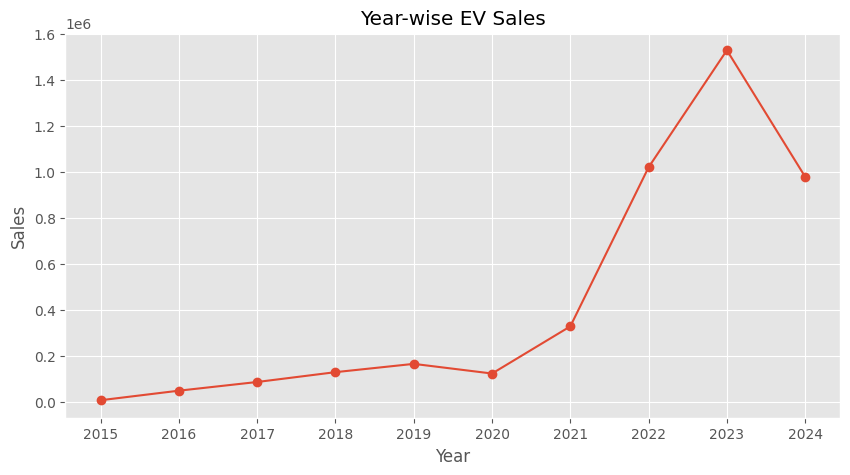

In [3]:
years=['2015','2016','2017','2018','2019','2020','2021','2022','2023','2024']
yearly_sales=df[years].sum()
plt.figure(figsize=(10,5))
plt.plot(years,yearly_sales,marker='o')
plt.title('Year-wise EV Sales')
plt.xlabel('Year');plt.ylabel('Sales')
plt.show()

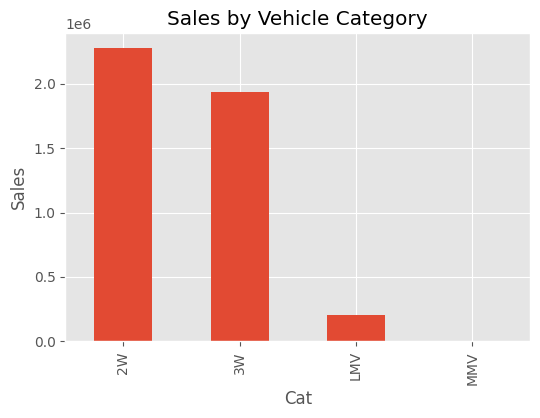

In [4]:
category_sales=df.groupby('Cat')[years].sum().sum(axis=1)
plt.figure(figsize=(6,4))
category_sales.plot(kind='bar')
plt.title('Sales by Vehicle Category')
plt.ylabel('Sales')
plt.show()

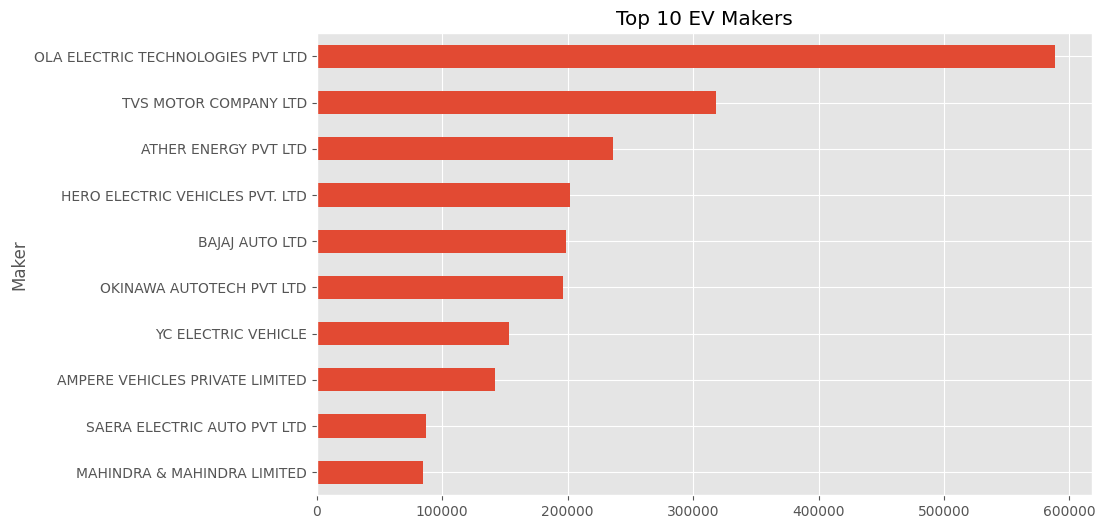

In [5]:
maker_sales=df.copy()
maker_sales['Total Sales']=maker_sales[years].sum(axis=1)
top10=maker_sales.groupby('Maker')['Total Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
top10.sort_values().plot(kind='barh')
plt.title('Top 10 EV Makers')
plt.show()

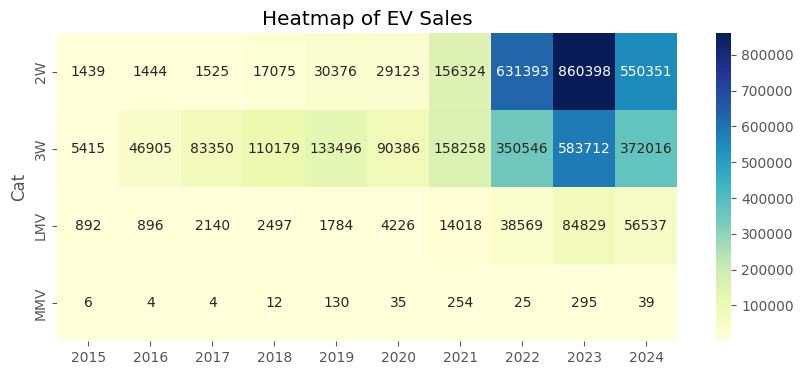

In [6]:
heat=df.groupby('Cat')[years].sum()
plt.figure(figsize=(10,4))
sns.heatmap(heat,annot=True,fmt='.0f',cmap='YlGnBu')
plt.title('Heatmap of EV Sales')
plt.show()

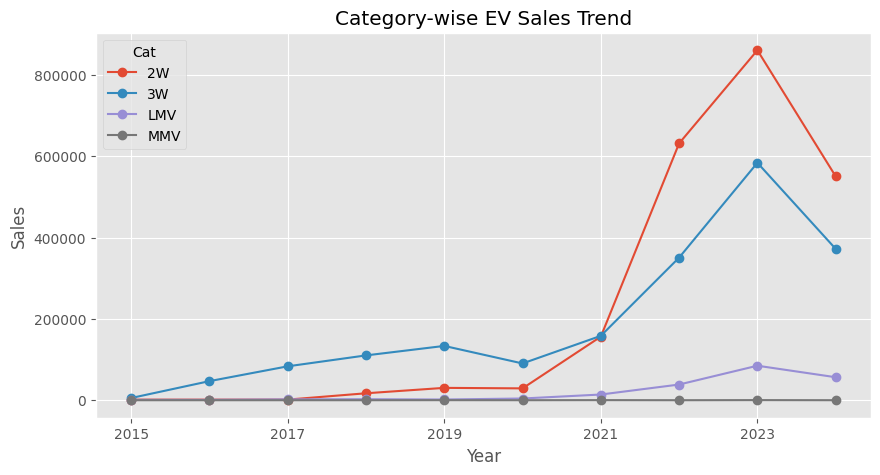

In [7]:
cat_year=df.groupby('Cat')[years].sum().T
cat_year.plot(figsize=(10,5),marker='o')
plt.title('Category-wise EV Sales Trend')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.show()

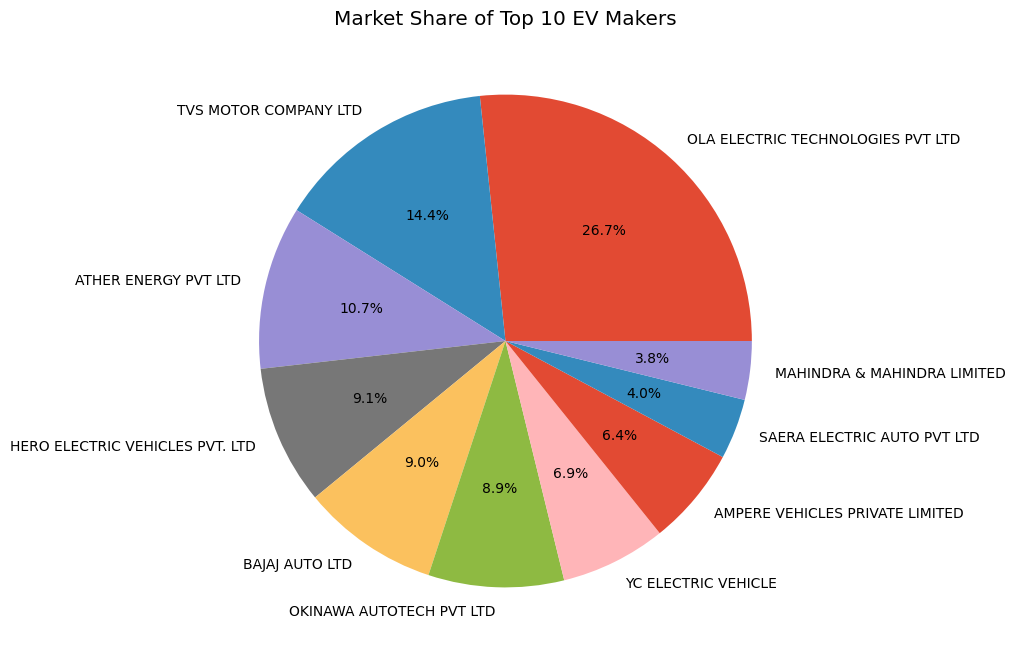

In [8]:
plt.figure(figsize=(8,8))
top10.plot(kind='pie',autopct='%1.1f%%')
plt.ylabel('')
plt.title('Market Share of Top 10 EV Makers')
plt.show()

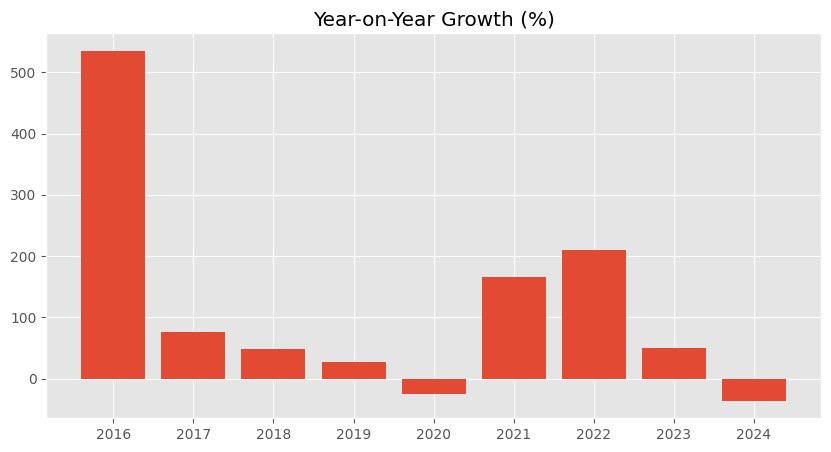

In [9]:
growth=yearly_sales.pct_change()*100
plt.figure(figsize=(10,5))
plt.bar(years,growth)
plt.title('Year-on-Year Growth (%)')
plt.show()